#**PART-A: Regression (Medical Cost Predidtion)**

#SECTION 1-Data Understanding

**1 Load the dataset and display**

In [ ]:
#importing dataset
import pandas as pd
df=pd.read_csv("insurance.csv",encoding='latin1')
print(df)

      age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]


In [ ]:
#information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
#1.Shape
print(df.shape)

(1338, 7)


In [ ]:
#2.column names
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [ ]:
#3.Data types
df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [ ]:
#printing first 5 rows
df.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


**2.check**

In [ ]:
#missing values in each row
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
#Missing values in dataset
df.isnull().sum().sum()

np.int64(0)

In [ ]:
#Duplicate rows
#i.checking Duplicates using boolean datatype
df.duplicated()


,0
0,False
1,False
2,False
3,False
4,False
...,...
1333,False
1334,False
1335,False
1336,False


In [ ]:
#ii.now using sum of all duplicates
df.duplicated().sum()

np.int64(1)

**3.Perform EDA**



*   Exploratory Data Analysis is the process of analyzing and summaring a dataset to understand its main characterstics before building a model




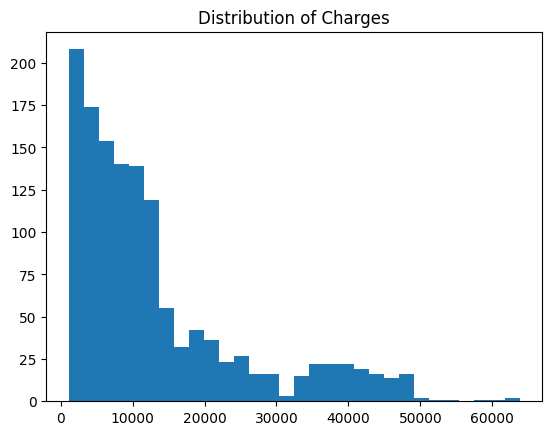

In [ ]:
#Distribution of charges
import pandas as pd
import matplotlib.pyplot as plt
plt.hist(df['charges'],bins=30)
plt.title('Distribution of Charges')

plt.show()

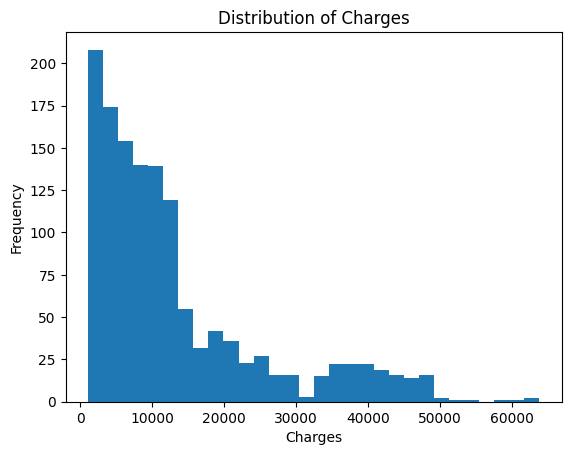

In [ ]:
import matplotlib.pyplot as plt
plt.hist(df['charges'],bins=30)
plt.title('Distribution of Charges')
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.show()

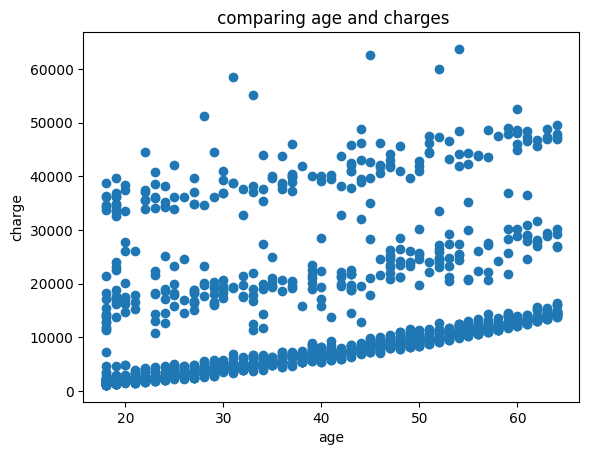

In [ ]:
#Scattar plot:age vs charges
plt.scatter(df['age'],df['charges'])
plt.xlabel('age');
plt.ylabel('charge')
plt.title(" comparing age and charges")
plt.show()

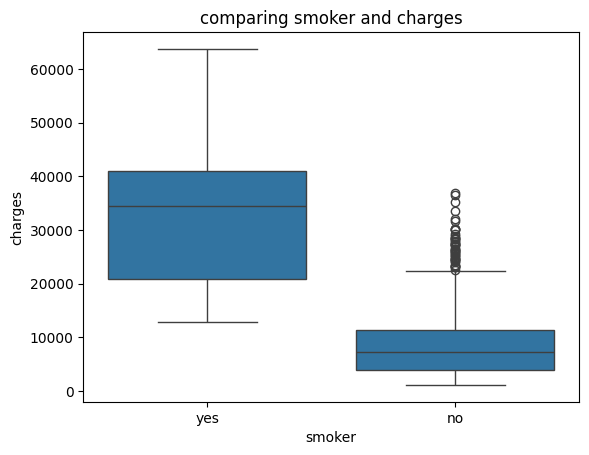

In [ ]:
#Boxplot:smoker vs charges
import seaborn as sns
sns.boxplot(x='smoker',y='charges',data=df)

plt.title("comparing smoker and charges")
plt.show()

In [ ]:
#Correlation heatmap
corr=df.corr(numeric_only=True)

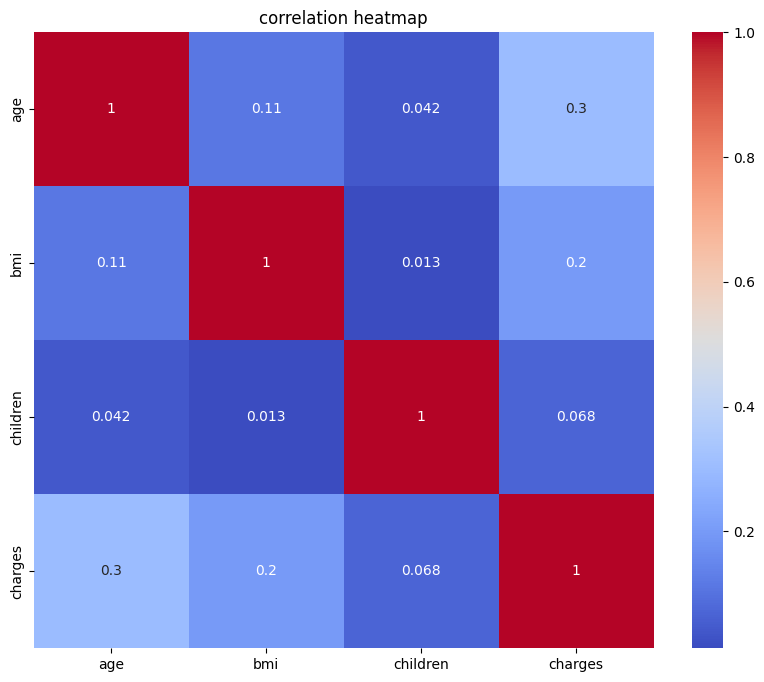

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title('correlation heatmap')
plt.show()


**4.observations from EDA**
  

  -
  

**A.Charge Distribution:**
     -The distribution of charges is right-slewed
     -Most have Lower medical charges
     -Few have high charges

**B.Age vs Charges Relationship**
      -there is positive correlation between age and charges
      -As age increases,medical expenses tend to increase
      -The relation appers moderatly linear

**c.Impact of Smoking on Charges**
     -Smoker have significant higer charges compared to non-smokers.
     -The median and spread of charges are much higher for smokers
     -Smoking is one of the strongest factors affecting insurance cost.


#**SECTION 2-DATA PREPROCESSING**

**5.Encoding categorial variables properly.**


Encoding means converting data into numerical format(0's and 1's) for computer understanding
  
  -The categorial variables are Age,Smoker,region

In [ ]:
df_encoded=pd.get_dummies(df,columns=['sex','smoker','region'],drop_first=True)
df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


**6.Separate features (x) and target(y).**

In [ ]:
x=df_encoded.drop('charges',axis=1)
y=df_encoded['charges']

In [ ]:
x.head()


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,False,True,False,False,True
1,18,33.770,1,True,False,False,True,False
2,28,33.000,3,True,False,False,True,False
3,33,22.705,0,True,False,True,False,False
4,32,28.880,0,True,False,True,False,False


In [ ]:
y.head()

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


**7.Testing(20%) and Training(80%)**

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
#as we know random_state ensures reproducibility

In [ ]:
print("x_train shape:",x_train.shape)
print("x_test shape:",x_test.shape)
print("y_train shape:",y_train.shape)
print("y_test shape:",y_test.shape)

x_train shape: (1070, 8)
x_test shape: (268, 8)
y_train shape: (1070,)
y_test shape: (268,)


**8.Appay feature scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler=StandardScaler()

In [ ]:
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [ ]:
print(x_train_scaled[:5])

[[ 0.47222651 -1.75652513  0.73433626 -1.0246016  -0.50874702  1.78316783
  -0.59966106 -0.5723141 ]
 [ 0.54331294 -1.03308239 -0.91119211 -1.0246016  -0.50874702 -0.56079971
  -0.59966106 -0.5723141 ]
 [ 0.8987451  -0.94368672 -0.91119211 -1.0246016  -0.50874702 -0.56079971
   1.66760869 -0.5723141 ]
 [-0.02537852  0.62239299  3.20262882 -1.0246016  -0.50874702 -0.56079971
   1.66760869 -0.5723141 ]
 [ 1.04091797 -1.50489287  1.55710045 -1.0246016  -0.50874702  1.78316783
  -0.59966106 -0.5723141 ]]


**9.why scaling is /isn't required?**


**when required?**
      -Scaling is required Distance-based models
      like KNN,K-Means,SVM
      -And it is required Gradient-Based Models like Logistic regression,Neural networks and linear regression
       Finally,
       ->Scaling is required because it prevents large-value features from dominating small-values features.
       ->It improves model stability and performance.

**when it is not Required?**
       -Scaling is not required when we work on Tree-Based Models(Decision Tree,random Forest and XGboost) beause
       -Trees do not calculate Distance
       -Trees looks about Order,they don't care about Magnitude


      


# **SECTION 3-Model Building**



**10.Train the Linear Regression model.**

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

**11.Display**
* 1.Intercept*

* 2.Coefficients*

In [ ]:
#Intercept-The value of y when all x values are 0
print("Intercept:",model.intercept_)

Intercept: -11931.21905032666


In [ ]:
#Coefficient-how much y changes when x increases by 1 unit
print("Slope(Coefficient):",model.coef_[0])
print("Coefficient:",model.coef_)

Slope(Coefficient): 256.97570583119415
Coefficient: [ 2.56975706e+02  3.37092552e+02  4.25278784e+02 -1.85916916e+01
  2.36511289e+04 -3.70677326e+02 -6.57864297e+02 -8.09799354e+02]


**12.Regression equation**

**1.For one feature**
y=b0+b1x
**2.Multiple features**
y=b0+b1x1+b2x2+......bnxn

**Here:**
   -y is target
   -x1,x2... are the featutes
   -b0 is Intercept
   -b1,b2,b3... are the Coefficients


# **SECTION 4-Model Evalutiont**

**13.Predict on test data**

In [ ]:
y_pred=model.predict(x_test_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
print(y_pred[:10])

[-22763.93070417 -24226.62754415  34631.33295356 -23270.00029079
  34053.07908974 -24241.24648918 -24955.99014786 -23312.31111816
 -24214.30745218 -23050.85257274]


In [ ]:
#comparing with actual values
print("Actual:",y_test[:10].values)
print("Predicted:",y_pred[:10])

Actual: [ 9095.06825  5272.1758  29330.98315  9301.89355 33750.2918   4536.259
  2117.33885 14210.53595  3732.6251  10264.4421 ]
Predicted: [-22763.93070417 -24226.62754415  34631.33295356 -23270.00029079
  34053.07908974 -24241.24648918 -24955.99014786 -23312.31111816
 -24214.30745218 -23050.85257274]


**14.calculations-MAE,MSE,RMSE R2 Score**

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np

In [ ]:
#MAE(Mean Absolute Error):Average absolute difference between actual and predicated values
#Tells average error magnitude
#Same unit as target(rupiees if charge)
mae=mean_absolute_error(y_test,y_pred)
print("MAE:",mae)

MAE: 27299.632991069157


In [ ]:
#MSE(Mean Squared error):Average of squared errors(square units)
#penalizes big mistakes strongly
#used in training optimization
mse=mean_squared_error(y_test,y_pred)
print("MSE:",mse)

MSE: 858634875.8320556


In [ ]:
#RMSE(Root Mean Squared Error):Penalizes large errors
#we simply square root of mse
#units:same as target
rmse=np.sqrt(mse)
print("RMSE:",rmse)

RMSE: 29302.472179528737


In [ ]:
#R2 Score():hoe much variance in target is explained by model(no units) based on the model good ness
r2=r2_score(y_test,y_pred)
print("R2 SCORE:",r2)

R2 SCORE: -4.530704615628721


**15.Plot**

*1.Actual vs predicted*

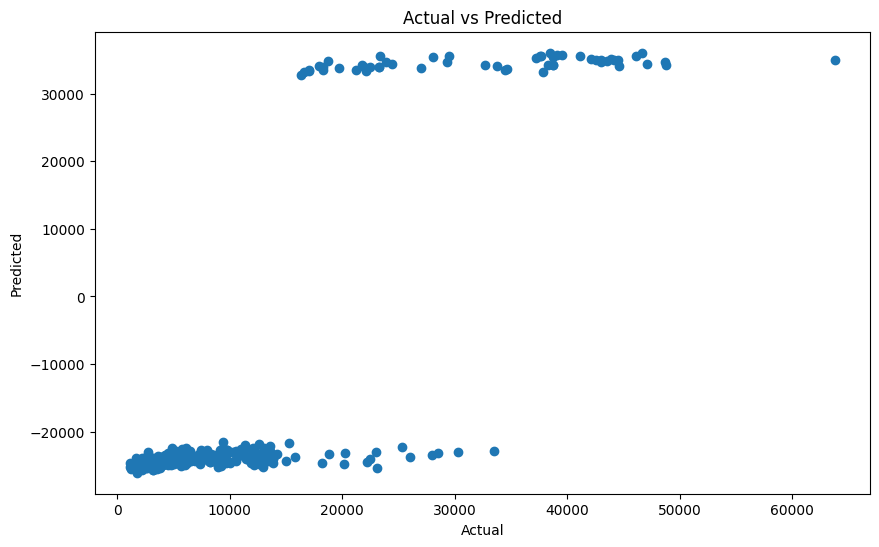

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(y_test,y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
#plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()])
plt.show()



*2.residual plot*

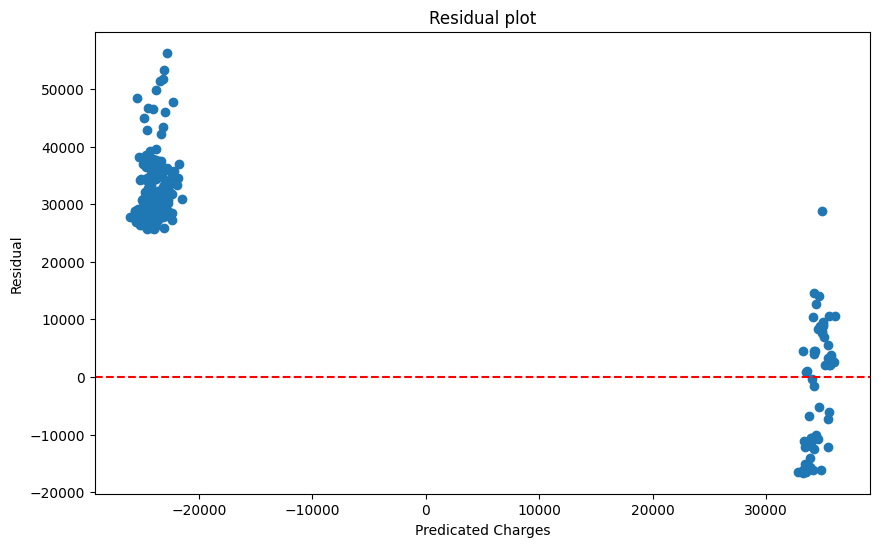

In [ ]:
#actual-predicted

residual=y_test-y_pred
plt.figure(figsize=(10,6))
plt.scatter(y_pred,residual)
plt.axhline(y=0,color='r',linestyle='--')
plt.xlabel("Predicated Charges")
plt.ylabel("Residual")
plt.title("Residual plot")
plt.show()

**16.Interpret R2 score**

In [ ]:
r2=r2_score(y_test,y_pred)
print("R2 SCORE:",r2)#this is in -ve so,i think this is not a good model

R2 SCORE: -4.530704615628721


#SECTION 5-BUSINESS INSIGHTS

**17.which variable impact charges the most**

**Answer**

As we see the above output the smokers coefficient is high so ,smokers charges most.

In [ ]:
coef_df=pd.DataFrame({'Feature':x.columns,'Coefficient':model.coef_})
coef_df

,Feature,Coefficient
0,age,256.975706
1,bmi,337.092552
2,children,425.278784
3,sex_male,-18.591692
4,smoker_yes,23651.128856
5,region_northwest,-370.677326
6,region_southeast,-657.864297
7,region_southwest,-809.799354


**18. How much more do smokers pay?**

**Answer**

As we seen in the above output on average,smokers pay approximetly 24000/- more than non-smokers








In [ ]:
#we can calculate using this also
df.groupby("smoker")["charges"].mean()

,charges
smoker,
no,8434.268298
yes,32050.231832


In [ ]:
32050.231832-8434.268298

23615.963534000002

**19. Is BMI statistically impactful?**
**Answer**

As we seen in the below output the t=11.860
and p>|t|==0.000 so,the BMI is very strongly significant




In [ ]:
print(x.dtypes)

age                   int64
bmi                 float64
children              int64
sex_male               bool
smoker_yes             bool
region_northwest       bool
region_southeast       bool
region_southwest       bool
dtype: object


In [ ]:
x=x.astype(float)#making all datatypes to float
y=y.astype(float)#making all datatypes to float
import statsmodels.api as sm
x_sm=sm.add_constant(x)
model_sm=sm.OLS(y,x_sm).fit()#fit ols()
print(model_sm.summary())


                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                Tue, 24 Feb 2026   Prob (F-statistic):               0.00
Time:                        10:38:40   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.194e+04    987.819  

**20. Can this model be used in production? Why or why not?**


**Answer**

No,This model is not ready for production now


because:



*   Residuals Are Not Normal
*   Very High Skewness in charges
*   Model validation is not done yet
*   No Interaction effects



